# 📘 Deep Learning Text Generation Learning Project
## Text Generation using Vanilla RNN, LSTM, and GRU

This notebook is built for students and beginners to understand how sequence models learn:

- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare Simple RNN vs LSTM vs GRU on the same text corpus and understand why gated architectures perform better.

## 🧠 Problem Statement

Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. Vanilla RNN
2. LSTM
3. GRU

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [51]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

## 📥 Load Text Corpus

We use a small built-in sample corpus so students can run this quickly. You can later replace it with:

- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [52]:
corpus = """
abhinav mishra is a computer science engineering student
abhinav studies at maharishi markandeshwar university
he enjoys learning data structures and algorithms
java is his preferred programming language
he practices coding problems regularly
he solves algorithmic challenges to improve his skills
abhinav is preparing for software engineering placements
he believes consistency is important for success
he studies object oriented programming concepts
he learns advanced java programming techniques
he works on machine learning projects
he developed an e waste classification system
the e waste classification project uses deep learning
mobilenetv2 is used for image classification tasks
tensorflow helps build deep learning models
keras simplifies neural network development
streamlit is used to create web applications
github helps manage source code repositories
abhinav regularly uploads projects to github
he likes building practical software solutions
he studies database management systems
sql is important for managing data
he learns computer networks and operating systems
he understands the basics of cloud computing
he enjoys exploring artificial intelligence concepts
machine learning enables systems to learn from data
deep learning uses neural networks with multiple layers
data preprocessing improves model performance
feature engineering helps extract useful information
classification models predict categories
regression models predict numerical values
natural language processing enables text understanding
computer vision enables image analysis
convolutional neural networks process images efficiently
recurrent neural networks process sequential data
lstm models capture long term dependencies
gru models provide efficient sequence learning
abhinav completed an ai ml internship
he gained experience in model development
he participated in hackathons and technical events
he enjoys solving real world problems using technology
software engineering requires logical thinking
clean code improves software quality
testing helps create reliable applications
algorithms improve computational efficiency
binary search is a powerful searching technique
dynamic programming solves complex optimization problems
abhinav studies regularly to improve his knowledge
he focuses on placement preparation and skill development
he wants to become a successful software engineer
continuous learning helps achieve career goals
artificial intelligence is transforming modern industries
technology creates opportunities for innovation
hard work and dedication lead to achievement
students should practice coding every day
problem solving is an essential engineering skill
abhinav believes in learning through projects
real world applications improve technical understanding
software development combines creativity and logic
he enjoys exploring emerging technologies
successful engineers adapt to changing technologies
machine learning has many practical applications
data science combines statistics and programming
deep learning models learn complex patterns
python is widely used in artificial intelligence
java is widely used in enterprise applications
abhinav works on improving his technical expertise
he aims to secure a good placement opportunity
consistent effort leads to continuous improvement
"""

## 🔤 Tokenization & Sequence Preparation

Word-level tokenizer: every sentence becomes a sequence of word indices, and we build progressively growing n-gram input sequences for next-word prediction.

In [53]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1
print(f"Total unique words: {total_words}")

input_sequences = []
for line in corpus.strip().split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i + 1])

max_seq_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_seq_len, padding="pre")

X = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Max sequence length: {max_seq_len}")

Total unique words: 236
X shape: (364, 7), y shape: (364, 236)
Max sequence length: 8


## 🏗️ Build Models: Simple RNN, LSTM, GRU

Same Embedding → recurrent layer → Dense(softmax) stack for all three, so only the recurrent cell changes between models.

In [54]:
EMBEDDING_DIM = 100
HIDDEN_UNITS = 128

def build_model(cell_type):
    model = Sequential(name=f"{cell_type}_model")
    model.add(Embedding(total_words, EMBEDDING_DIM, input_length=max_seq_len - 1))

    if cell_type == "SimpleRNN":
        model.add(SimpleRNN(HIDDEN_UNITS))
    elif cell_type == "LSTM":
        model.add(LSTM(HIDDEN_UNITS))
    elif cell_type == "GRU":
        model.add(GRU(HIDDEN_UNITS))
    else:
        raise ValueError(f"Unknown cell_type: {cell_type}")

    model.add(Dense(total_words, activation="softmax"))
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

rnn_model = build_model("SimpleRNN")
lstm_model = build_model("LSTM")
gru_model = build_model("GRU")

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "SimpleRNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_24 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 🚀 Train All Three Models

In [55]:
EPOCHS = 200

print("Training Simple RNN...")
rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)

print("Training LSTM...")
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)

print("Training GRU...")
gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)

print("Done training all three models.")

Training Simple RNN...
Training LSTM...
Training GRU...
Done training all three models.


## 📊 Compare Training Loss

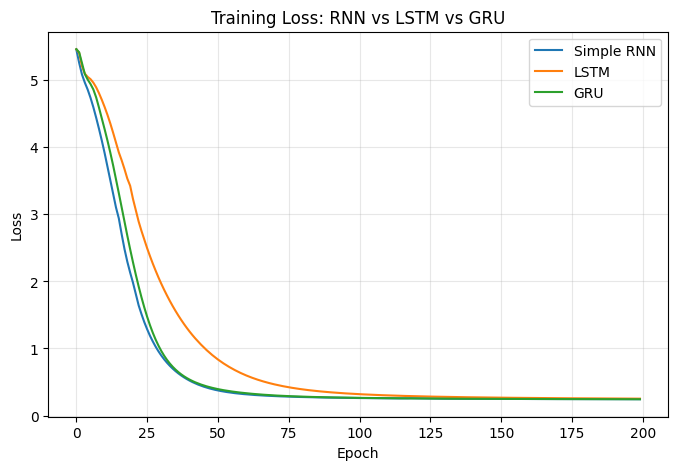

Model       Final Loss    Final Accuracy  
SimpleRNN   0.2437        0.8846          
LSTM        0.2521        0.8874          
GRU         0.2436        0.8846          


In [56]:
plt.figure(figsize=(8, 5))
plt.plot(rnn_history.history["loss"], label="Simple RNN")
plt.plot(lstm_history.history["loss"], label="LSTM")
plt.plot(gru_history.history["loss"], label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss: RNN vs LSTM vs GRU")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"{'Model':<12}{'Final Loss':<14}{'Final Accuracy':<16}")
print(f"{'SimpleRNN':<12}{rnn_history.history['loss'][-1]:<14.4f}{rnn_history.history['accuracy'][-1]:<16.4f}")
print(f"{'LSTM':<12}{lstm_history.history['loss'][-1]:<14.4f}{lstm_history.history['accuracy'][-1]:<16.4f}")
print(f"{'GRU':<12}{gru_history.history['loss'][-1]:<14.4f}{gru_history.history['accuracy'][-1]:<16.4f}")

## ✍️ Generate Text

Given a seed phrase, each model predicts the next word repeatedly, feeding its own output back in as input.

In [57]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len - 1, padding="pre")
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(predicted_probs)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

seed = "abhinav is a"
print("SimpleRNN:", generate_text(rnn_model, seed, next_words=10))
print("LSTM:     ", generate_text(lstm_model, seed, next_words=10))
print("GRU:      ", generate_text(gru_model, seed, next_words=10))

SimpleRNN: abhinav is a for software engineering placements creativity thinking logic from data science
LSTM:      abhinav is a for software engineering placements student student opportunity layers layers student
GRU:       abhinav is a computer science engineering skill opportunity opportunity opportunity layers student engineer


# 📚 Student Learning Tasks

### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion

- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**